## Empleo de Algoritmos Clásicos de Machine Learning en Imágenes

In [ ]:
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split


In [ ]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

# Las imagenes son de tamaño 28x28.
# Pero las imágenes ya vienen desdobladas en vectores (28x28=784)
# Son 70k imágenes

print(f"Forma de los datos: {X.shape}")
print(f"Estructura de las etiquetas: {y.shape}")

Forma de los datos: (70000, 784)
Estructura de las etiquetas: (70000,)


Etiqueta de la imagen: 6


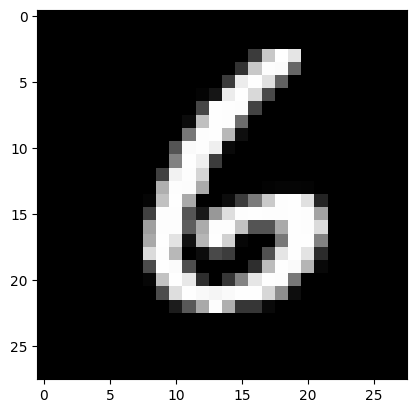

In [ ]:
# Por ejemplo, se muestra la imagen 1:

imagen = X[6000].reshape(28,28)
etiqueta = y[6000]

print(f"Etiqueta de la imagen: {etiqueta}")
plt.imshow(imagen, cmap="gray")
plt.show()

In [ ]:
# Se seleccionan los grupos de imagenes y etiquetas para el entrenamiento
# y las pruebas. No se debe probar con el mismo grupo de entrenamiento (sesgos).
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=5)
plt.show()

In [ ]:
# Tomo sólo un grupo de datos. Si usamos todos tardará tiempo considerable 
# en el entrenamiento y predicción

X_train = X_train
y_train = y_train

X_test = X_test
y_test = y_test

In [ ]:
# Uso de máquinas de soporte vectorial (SVM) para clasificación

from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

svm = LinearSVC()
svm.fit(X_train, y_train) # Entrenamiento del modelo
y_pred = svm.predict(X_test) # Se obtienen las predicciones con el modelo entrenado


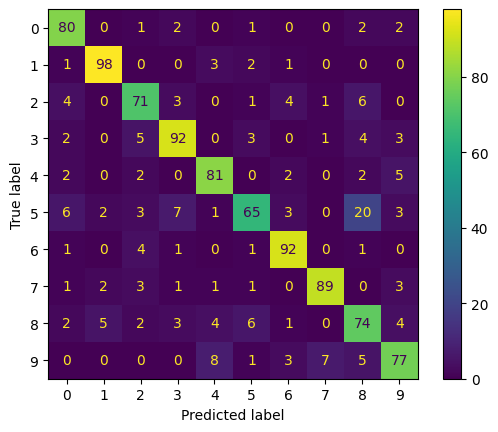

In [ ]:
cfn_mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cfn_mat,
                              display_labels=svm.classes_)
disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

rp = classification_report(y_test, y_pred)
print(rp)

              precision    recall  f1-score   support

           0       0.81      0.91      0.86        88
           1       0.92      0.93      0.92       105
           2       0.78      0.79      0.78        90
           3       0.84      0.84      0.84       110
           4       0.83      0.86      0.84        94
           5       0.80      0.59      0.68       110
           6       0.87      0.92      0.89       100
           7       0.91      0.88      0.89       101
           8       0.65      0.73      0.69       101
           9       0.79      0.76      0.78       101

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000

